## Search for Strategic Manipulations

This notebook contains the necessary functions to 
 walks through the steps needed to generate a course schedule using real Fall 2024 class data.

The code relies on the **course-data** repository to parse and build the student objects, and on the **yankee-swap-framework** repository to run the allocation algorithms. 


#### Imports

In [1]:
import numpy as np
import copy
import random
import pandas as pd
import os

from fair.allocation import (
    yankee_swap,
    round_robin,
    serial_dictatorship,
    integer_linear_program,
)
from fair.optimization import StudentAllocationProgram
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
import qsurvey


#### Define Parameters

In [2]:
status_color_map = {
    1: "lightsteelblue",
    2: "blue",
    3: "forestgreen",
    4: "darkkhaki",
    5: "darkorange",
    6: "red",
}
status_max_course_map = {
    1: 6,
    2: 6,
    3: 6,
    4: 6,
    5: 4,
    6: 4,
}
status_crs_prefix_map = {
    1: ["1", "2", "3"],
    2: ["1", "2", "3", "4"],
    3: ["1", "2", "3", "4", "5"],
    4: ["2", "3", "4", "5", "6"],
    5: ["5", "6"],
    6: ["5", "6"],
}
NUM_STUDENTS_PER_STATUS = {
    1: 239,
    2: 327,
    3: 408,
    4: 573,
    5: 613,
    6: 148,
}

pref_thresh = 100
SPARSE = False

#### Generate schedule and students

Read survey data form `survey_data.csv`...

In [3]:
survey_file = "../resources/survey_data.csv"
schedule_file = "../resources/anonymized_courses.xlsx"
mapping_file = "../resources/survey_column_mapping.csv"

mp = qsurvey.QMapper(mapping_file)
qd = qsurvey.QSchedule(schedule_file)
crs_sec_cap_map = qd.capacities()
qs = qsurvey.QSurvey(survey_file, mp, list(crs_sec_cap_map.keys()))
course_map = mp.mapping(qs.all_courses)
all_courses = [crs for crs in course_map.keys()]
features = mp.features(course_map)
course, slot, weekday, section = features
schedule = mp.schedule(course_map, crs_sec_cap_map, features)
students, responses, statuses = qs.students(
    course_map,
    all_courses,
    features,
    schedule,
    status_max_course_map,
    pref_thresh,
    SPARSE,
)
student_status_map = {students[i]: status for i, status in enumerate(statuses)}
student_resp_map = {students[i]: response for i, response in enumerate(responses)}
course_cap_map = {
    crs: crs_sec_cap_map[course_map[crs]["course num"]][int(course_map[crs]["section"])]
    for crs in all_courses
}
all_students = [
    student for student in students if len(student.student.preferred_courses) > 0
]

n_responses_per_status = np.zeros(6)
for student in all_students:
    student_status = int(student_status_map[student])
    n_responses_per_status[student_status - 1] += 1


/Users/paula/Documents/Research/course-allocation/collaboration/course-allocation-data/src/qsurvey/__init__.py:320: UserWarning: total courses not specified; skipping student
  warnings.warn("total courses not specified; skipping student")


In [4]:
rate = 0.1

n_per_status = [round(NUM_STUDENTS_PER_STATUS[i + 1] * rate) for i in range(6)]
for sche in schedule:
    sche.capacity = max(1,round(sche.capacity * rate))

In [5]:
capacities = [item.capacity for item in schedule]
print(n_per_status)
min(capacities)

[24, 33, 41, 57, 61, 15]


1

#### Allocation Algorithms: Binary submodular scenario

With the built instance (students and schedule), we can run each of the allocation algorithms, and evaluate their performance according to USW, NSW and Envy metrics. 

#### Allocation Algorithms: Additive scenario

With the same instance, we run the algorithms again, but now considering that students have additive valuation functions over the items, given by their survey responses. In this case, ILP, Serial Dictatorship and Round Robin run with additive utilities, while Yankee Swap runs considering binary submodular valuations, and taking into account the response values only for tie-breaking purposes. 

In [6]:
# Define the response values for each student
c = np.vstack([student_resp_map[student] for student in students])-1

In [7]:
random.seed(0)
reduced_students = []
for status in range(1, 7):
    students_status = [
        student for student in all_students if student_status_map[student] == status
    ]
    selected_students = random.sample(students_status, n_per_status[status - 1])
    reduced_students = [*reduced_students, *selected_students]

students = reduced_students
NUM_STUDENTS = len(students)
print("Num students,", NUM_STUDENTS)

students.sort(key=lambda x: student_status_map[x])
students.reverse()

valuations = np.vstack([student_resp_map[student] for student in students]) - 1

Num students, 231


In [8]:
schedule_copy = [copy.copy(item) for item in schedule]
for i in range(len(schedule_copy)):
    schedule_copy[i].capacity= 1

X_OPT = np.zeros([len(schedule), len(students)], dtype=int)
for student_idx in range(len(students)):
    small_ilp_students = students[student_idx : student_idx + 1]
    c_small_ilp = np.array([valuations[student_idx]])
    orig_students = [student.student for student in small_ilp_students]
    program = StudentAllocationProgram(orig_students, schedule_copy).compile()
    opt_alloc = program.formulateUSW(valuations=c_small_ilp.flatten()).solve()
    X_OPT[:, student_idx] = opt_alloc

In [9]:
X_YS = yankee_swap(students, schedule, valuations=valuations)

OPT_utilities = np.diag(np.dot(valuations, X_OPT))
YS_utilities = np.diag(np.dot(valuations, X_YS))

print(OPT_utilities-YS_utilities)

[ 0.  0.  1.  0.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  6.  5.  0.
  6.  6.  6.  5.  4.  7.  6.  6.  0.  0.  3.  0.  4.  5.  4.  6.  6.  5.
  2.  6.  6.  6.  5.  5.  0.  1.  5.  7.  7.  4.  6.  5.  6.  1.  6.  0.
  3.  6.  1.  1.  4.  5.  0.  6.  5.  4.  8.  3.  4.  7.  6.  5.  0.  0.
  4.  8.  3.  4.  6.  5.  0.  0.  0. 13.  0.  0.  1.  1.  2.  6.  0.  5.
  0.  0.  0.  0.  0.  0.  0.  0.  7.  6.  2.  4.  6.  0. 11.  0.  7.  7.
  0.  0.  0.  0.  3.  7.  0.  0.  0.  0.  0. 11.  6.  0.  0.  6.  6. 12.
  7.  0.  6.  7.  0.  1.  0.  0.  1.  1.  0. 10.  0.  4.  0.  1.  0.  0.
  4.  6.  0.  0.  4.  1.  2.  8.  0.  4. 10. 14. 14.  0.  3.  0.  0.  4.
  5. 11.  0.  8.  7.  0.  0.  0. 10.  0.  6.  6.  0.  8. 14.  0.  0.  2.
 14.  2.  0.  6.  0. 13.  1.  6.  1. 17. 12.  0.  0.  6.  0.  5. 16.  0.
 11.  0. 18.  0. 12.  0.  2.  9.  1.  6.  0.  2.  7.  4.  0.  3.  0.  0.
  6.  0.  7. 10.  4.  7.  0.  6.  0.  5.  4.  0.  1.  1.  9.]


In [10]:
results_file = "manipulation_results_YS.csv"

# create empty file if it does not exist
if not os.path.exists(results_file):

    empty_df = pd.DataFrame(columns=[
        "student",
        "student_status",
        "strategy",
        "gain",
        "old_utility",
        "new_utility",
        "regret_before",
        "regret_after",
        "old_bundle",
        "new_bundle",
        "desired_items",
        "true_preferences",
        "reported_preferences",
    ])

    empty_df.to_csv(results_file, index=False)

In [11]:
##############################################################################
# CONSTANTS
##############################################################################

MIN_UTILITY = 0
MAX_UTILITY = 7


##############################################################################
# HELPERS
##############################################################################

def clip_utilities(v):
    return np.clip(v, MIN_UTILITY, MAX_UTILITY)


def compute_utilities(valuations, allocation):
    return np.diag(valuations @ allocation)


def get_assigned_items(X, student_idx):
    return np.where(X[:, student_idx] != 0)[0]


def get_missed_opt_items(X_OPT, X_YS, student_idx):
    return np.where(
        (X_OPT[:, student_idx] != 0) &
        (X_YS[:, student_idx] == 0)
    )[0]


##############################################################################
# HEURISTICS
##############################################################################

def heuristic_boost_missed(
    true_vals,
    assigned_items,
    missed_items,
    boost=2,
    penalty=2
):

    v = true_vals.copy()

    for c in missed_items:
        if v[c] > 0:
            v[c] = min(MAX_UTILITY, v[c] + boost)

    for c in assigned_items:
        if v[c] > 0:
            v[c] = max(MIN_UTILITY, v[c] - penalty)

    return clip_utilities(v)


def heuristic_only_missed(
    true_vals,
    missed_items
):

    v = np.zeros_like(true_vals)

    for c in missed_items:
        if true_vals[c] > 0:
            v[c] = MAX_UTILITY

    return clip_utilities(v)


def heuristic_promote_single_missed(
    true_vals,
    missed_item
):

    v = true_vals.copy()

    v[missed_item] = MAX_UTILITY

    for j in range(len(v)):
        if j != missed_item and v[j] > 0:
            v[j] = max(MIN_UTILITY, v[j] - 1)

    return clip_utilities(v)


def heuristic_demote_assigned(
    true_vals,
    assigned_items
):

    v = true_vals.copy()

    for c in assigned_items:
        if v[c] > 0:
            v[c] = max(MIN_UTILITY, v[c] - 3)

    return clip_utilities(v)


##############################################################################
# MAIN EXPERIMENT
##############################################################################

def run_manipulation_experiment(
    valuations,
    X_OPT,
    X_YS,
    students,
    schedule,
    threshold=5,
    max_students=5,   # <-- NEW
):
    """
    Runs manipulation experiments on unhappy students.

    Students are processed in decreasing regret order.
    Only the top `max_students` most unhappy students are tested.
    """

    results = []

    ##########################################################################
    # TRUE UTILITIES
    ##########################################################################

    OPT_utilities = compute_utilities(valuations, X_OPT)
    YS_utilities = compute_utilities(valuations, X_YS)

    regret = OPT_utilities - YS_utilities

    ##########################################################################
    # SORT STUDENTS BY REGRET
    ##########################################################################

    unhappy_students = np.where(regret >= threshold)[0]

    unhappy_students = unhappy_students[
        np.argsort(regret[unhappy_students])[::-1]
    ]

    ##########################################################################
    # KEEP ONLY TOP max_students
    ##########################################################################

    unhappy_students = unhappy_students[:max_students]

    print(f"\nTesting top {len(unhappy_students)} unhappy students")

    ##########################################################################
    # LOOP OVER STUDENTS
    ##########################################################################

    for s in unhappy_students:

        print("\n==================================================")
        print(f"Student {s}")

        assigned_items = get_assigned_items(X_YS, s)

        missed_items = get_missed_opt_items(X_OPT, X_YS, s)

        true_utility = YS_utilities[s]

        print("Current utility:", true_utility)
        print("OPT utility:", OPT_utilities[s])
        print("Regret:", regret[s])

        print("Assigned items:", assigned_items)
        print("Missed OPT items:", missed_items)

        if len(missed_items) == 0:
            print("No missed OPT items")
            continue

        ######################################################################
        # GENERATE STRATEGIES
        ######################################################################

        strategies = []

        strategies.append((
            "boost_missed",
            heuristic_boost_missed(
                valuations[s],
                assigned_items,
                missed_items
            )
        ))

        strategies.append((
            "only_missed",
            heuristic_only_missed(
                valuations[s],
                missed_items
            )
        ))

        strategies.append((
            "demote_assigned",
            heuristic_demote_assigned(
                valuations[s],
                assigned_items
            )
        ))

        for c in missed_items:

            strategies.append((
                f"promote_single_{c}",
                heuristic_promote_single_missed(
                    valuations[s],
                    c
                )
            ))

        ######################################################################
        # TEST STRATEGIES
        ######################################################################

        for strategy_name, fake_vals in strategies:

            print(f"\nTrying strategy: {strategy_name}")

            ##################################################################
            # MODIFY ONLY THIS STUDENT
            ##################################################################

            reported_vals = valuations.copy()

            reported_vals[s] = fake_vals

            ##################################################################
            # RUN YANKEE SWAP
            ##################################################################

            X_new = yankee_swap(
                students,
                schedule,
                valuations=reported_vals,
            )

            ##################################################################
            # TRUE UTILITY
            ##################################################################

            new_utility = valuations[s] @ X_new[:, s]

            gain = new_utility - true_utility

            ##################################################################
            # STORE PROFITABLE DEVIATIONS
            ##################################################################


            if gain > 0:

                new_bundle = get_assigned_items(X_new, s)

                print("PROFITABLE DEVIATION FOUND")
                print("Gain:", gain)

                ##########################################################################
                # SAVE ONLY ITEMS THE STUDENT ACTUALLY CARES ABOUT
                ##########################################################################

                desired_items = np.where(valuations[s] > 0)[0]

                true_preferences = valuations[s, desired_items]
                reported_preferences = fake_vals[desired_items]

                ##########################################################################
                # STORE RESULT
                ##########################################################################

                result_row = {
                    "student": s,
                    "student_status": student_status_map[students[s]],
                    "strategy": strategy_name,

                    "gain": gain,

                    "old_utility": true_utility,
                    "new_utility": new_utility,

                    "regret_before": regret[s],
                    "regret_after": OPT_utilities[s] - new_utility,

                    "old_bundle": assigned_items.tolist(),
                    "new_bundle": new_bundle.tolist(),

                    "desired_items": desired_items.tolist(),

                    "true_preferences": true_preferences.tolist(),
                    "reported_preferences": reported_preferences.tolist(),
                }
                results.append(result_row)

                pd.DataFrame([result_row]).to_csv(
                    results_file,
                    mode="a",
                    header=False,
                    index=False
                )

    return pd.DataFrame(results)

In [12]:
df = run_manipulation_experiment(
    valuations,
    X_OPT,
    X_YS,
    students,
    schedule,
    threshold=5,
    max_students=5)


Testing top 5 unhappy students

Student 200
Current utility: 21.0
OPT utility: 39.0
Regret: 18.0
Assigned items: [19 28 34]
Missed OPT items: [20 35 36 49 50]

Trying strategy: boost_missed

Trying strategy: only_missed

Trying strategy: demote_assigned

Trying strategy: promote_single_20

Trying strategy: promote_single_35

Trying strategy: promote_single_36

Trying strategy: promote_single_49

Trying strategy: promote_single_50

Student 189
Current utility: 20.0
OPT utility: 37.0
Regret: 17.0
Assigned items: [28 32 39]
Missed OPT items: [27 29 36 52 54]

Trying strategy: boost_missed

Trying strategy: only_missed

Trying strategy: demote_assigned

Trying strategy: promote_single_27

Trying strategy: promote_single_29
PROFITABLE DEVIATION FOUND
Gain: 3.0

Trying strategy: promote_single_36

Trying strategy: promote_single_52

Trying strategy: promote_single_54

Student 196
Current utility: 21.0
OPT utility: 37.0
Regret: 16.0
Assigned items: [27 29 33]
Missed OPT items: [32 40 45 57]


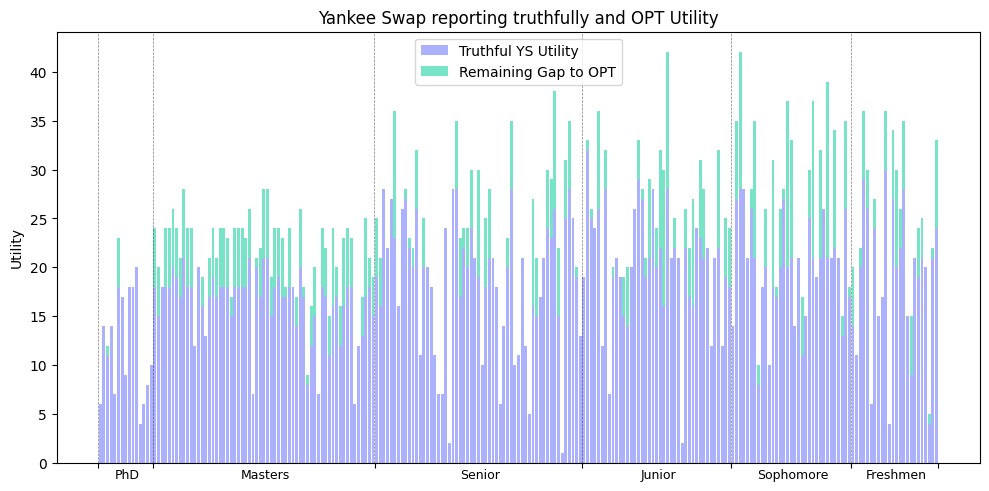

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotly.colors import qualitative

palette = qualitative.Plotly
# palette = [sns.color_palette("colorblind")[i] for i in [3,0,2]]
palette = [palette[i] for i in [0, 1, 2, 4, 3, 5]]
faded_palette = [color + "88" for color in palette]
##############################################################################
# LOAD MANIPULATION RESULTS
##############################################################################

results_df = pd.read_csv("manipulation_results_YS.csv")

##############################################################################
# TRUE UTILITIES
##############################################################################

OPT_utilities = np.diag(valuations @ X_OPT)
YS_utilities = np.diag(valuations @ X_YS)

num_students = len(YS_utilities)

##############################################################################
# COMPUTE BEST MANIPULATION GAIN PER STUDENT
##############################################################################

# default = no profitable manipulation found
max_gains = np.zeros(num_students)

if len(results_df) > 0:

    grouped = results_df.groupby("student")["gain"].max()

    for student, gain in grouped.items():
        max_gains[int(student)] = gain

##############################################################################
# PLOT COMPONENTS
##############################################################################

# green = truthful YS utility
truthful = YS_utilities

# red = extra utility from best manipulation
manipulation_gain = max_gains

# blue = remaining gap to OPT
remaining_gap = OPT_utilities - (truthful + manipulation_gain)

# numerical safety
remaining_gap = np.maximum(remaining_gap, 0)

##############################################################################
# PLOT
##############################################################################

x = np.arange(num_students)

plt.figure(figsize=(10, 5))

##############################################################################
# BASE: truthful utility
##############################################################################

plt.bar(
    x,
    truthful,
    color=faded_palette[0],
    label="Truthful YS Utility"
)

##############################################################################
# STACK: manipulation gain
##############################################################################

plt.bar(
    x,
    manipulation_gain,
    bottom=truthful,
    color=faded_palette[2],
)

##############################################################################
# STACK: remaining gap to OPT
##############################################################################

plt.bar(
    x,
    remaining_gap,
    bottom=truthful + manipulation_gain,
    color=faded_palette[2],
    label="Remaining Gap to OPT"
)

##############################################################################
# LABELS
##############################################################################

# plt.xlabel("Student")
plt.ylabel("Utility")
# n_per_status.reverse()
status_ticks=[*[sum(n_per_status[:i]) for i in range(len(n_per_status))], len(students)]
plt.xticks([i-0.5 for i in status_ticks],["" for i in status_ticks])

status_names = ["PhD", "Masters", "Senior", "Junior", "Sophomore", "Freshmen"]
for i in range(len(status_ticks)-1):
    plt.axvline(x=status_ticks[i]-0.6, linestyle="--", color="k", alpha=0.5, linewidth=0.5)
    plt.text(
        (status_ticks[i]+status_ticks[i+1])/2,      # x
        -0.035,   # y in axis coordinates
        status_names[i],
        transform=plt.gca().get_xaxis_transform(),
        ha="center", 
        fontsize=9
    )

plt.title(
    "Yankee Swap reporting truthfully and OPT Utility"
)

plt.legend()

plt.tight_layout()

plt.show()

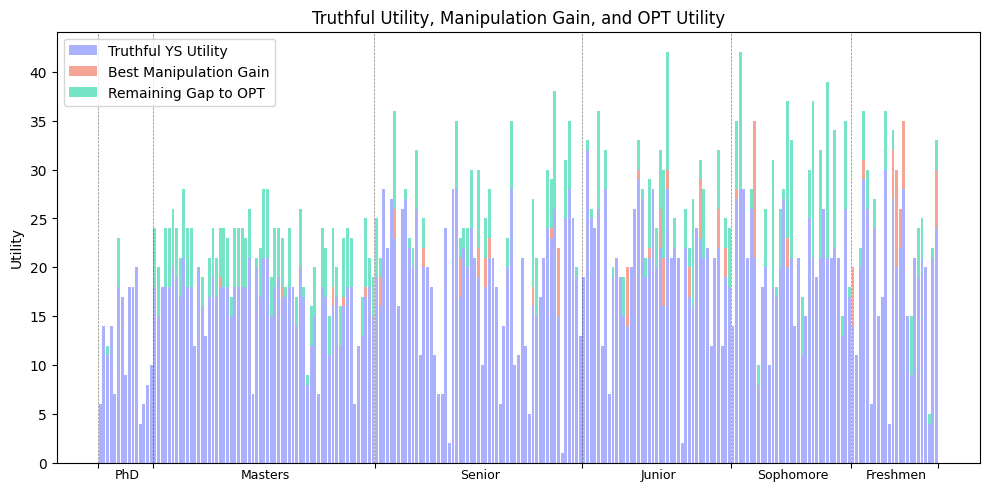

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotly.colors import qualitative

palette = qualitative.Plotly
# palette = [sns.color_palette("colorblind")[i] for i in [3,0,2]]
palette = [palette[i] for i in [0, 1, 2, 4, 3, 5]]
faded_palette = [color + "88" for color in palette]
##############################################################################
# LOAD MANIPULATION RESULTS
##############################################################################

results_df = pd.read_csv("manipulation_results_YS.csv")

##############################################################################
# TRUE UTILITIES
##############################################################################

OPT_utilities = np.diag(valuations @ X_OPT)
YS_utilities = np.diag(valuations @ X_YS)

num_students = len(YS_utilities)

##############################################################################
# COMPUTE BEST MANIPULATION GAIN PER STUDENT
##############################################################################

# default = no profitable manipulation found
max_gains = np.zeros(num_students)

if len(results_df) > 0:

    grouped = results_df.groupby("student")["gain"].max()

    for student, gain in grouped.items():
        max_gains[int(student)] = gain

##############################################################################
# PLOT COMPONENTS
##############################################################################

# green = truthful YS utility
truthful = YS_utilities

# red = extra utility from best manipulation
manipulation_gain = max_gains

# blue = remaining gap to OPT
remaining_gap = OPT_utilities - (truthful + manipulation_gain)

# numerical safety
remaining_gap = np.maximum(remaining_gap, 0)

##############################################################################
# PLOT
##############################################################################

x = np.arange(num_students)

plt.figure(figsize=(10, 5))

##############################################################################
# BASE: truthful utility
##############################################################################

plt.bar(
    x,
    truthful,
    color=faded_palette[0],
    label="Truthful YS Utility"
)

##############################################################################
# STACK: manipulation gain
##############################################################################

plt.bar(
    x,
    manipulation_gain,
    bottom=truthful,
    color=faded_palette[1],
    label="Best Manipulation Gain"
)

##############################################################################
# STACK: remaining gap to OPT
##############################################################################

plt.bar(
    x,
    remaining_gap,
    bottom=truthful + manipulation_gain,
    color=faded_palette[2],
    label="Remaining Gap to OPT"
)

##############################################################################
# LABELS
##############################################################################

# plt.xlabel("Student")
plt.ylabel("Utility")
# n_per_status.reverse()
status_ticks=[*[sum(n_per_status[:i]) for i in range(len(n_per_status))], len(students)]
plt.xticks([i-0.5 for i in status_ticks],["" for i in status_ticks])

status_names = ["PhD", "Masters", "Senior", "Junior", "Sophomore", "Freshmen"]
for i in range(len(status_ticks)-1):
    plt.axvline(x=status_ticks[i]-0.6, linestyle="--", color="k", alpha=0.5, linewidth=0.5)
    plt.text(
        (status_ticks[i]+status_ticks[i+1])/2,      # x
        -0.035,   # y in axis coordinates
        status_names[i],
        transform=plt.gca().get_xaxis_transform(),
        ha="center", 
        fontsize=9
    )

plt.title(
    "Truthful Utility, Manipulation Gain, and OPT Utility"
)

plt.legend()

plt.tight_layout()

plt.show()

In [28]:
[sum(n_per_status[:i+1]) for i in range(len(n_per_status))]

[24, 57, 98, 155, 216, 231]

In [60]:
n_per_status

[15, 61, 57, 41, 33, 24]

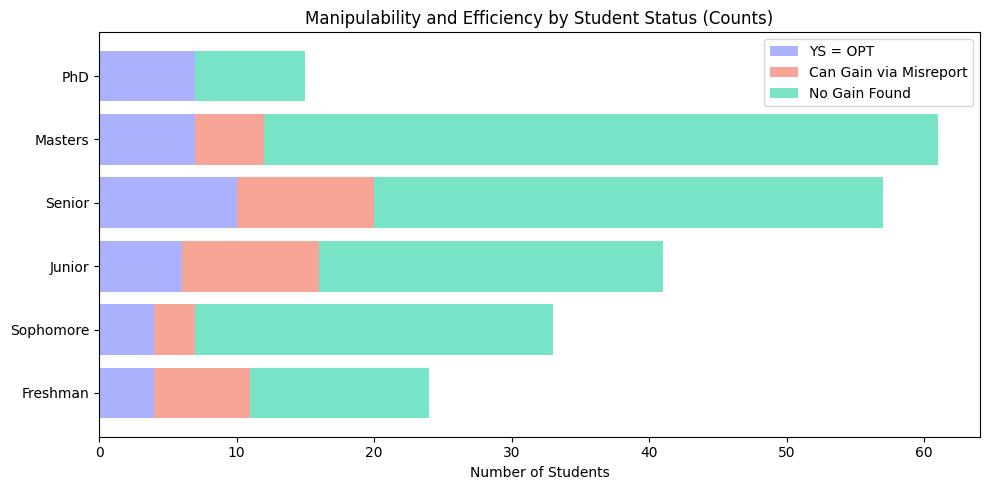

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


##############################################################################
# LOAD DATA
##############################################################################

df = pd.read_csv("manipulation_results_YS.csv")

# student_status_map: array or dict mapping student -> status
# e.g. student_status_map[s] = 1..6

num_students = len(students)


##############################################################################
# STATUS SETUP
##############################################################################

statuses = sorted(set(student_status_map.values()))
status_to_index = {s: i for i, s in enumerate(statuses)}

matched = np.zeros(len(statuses))
can_gain = np.zeros(len(statuses))
no_gain = np.zeros(len(statuses))


##############################################################################
# STUDENTS THAT CAN GAIN (FROM CSV)
##############################################################################

can_gain_students = set(df["student"].astype(int).unique())


##############################################################################
# CLASSIFY STUDENTS
##############################################################################

for s in range(num_students):

    st = student_status_map[students[s]]
    idx = status_to_index[st]

    ys_bundle = set(np.where(X_YS[:, s] != 0)[0])
    opt_bundle = set(np.where(X_OPT[:, s] != 0)[0])

    is_matched = (ys_bundle == opt_bundle)

    if is_matched:
        matched[idx] += 1

    elif s in can_gain_students:
        can_gain[idx] += 1

    else:
        no_gain[idx] += 1


##############################################################################
# PLOT RAW COUNTS
##############################################################################

y = np.arange(len(statuses))

plt.figure(figsize=(10, 5))

plt.barh(y, matched, label="YS = OPT", color=faded_palette[0])
plt.barh(y, can_gain, left=matched, label="Can Gain via Misreport", color=faded_palette[1])
plt.barh(y, no_gain, left=matched + can_gain, label="No Gain Found", color=faded_palette[2])


##############################################################################
# LABELS
##############################################################################

status_labels = {
    1: "Freshman",
    2: "Sophomore",
    3: "Junior",
    4: "Senior",
    5: "Masters",
    6: "PhD"
}

plt.yticks(
    y,
    [status_labels[s] for s in statuses]
)

plt.xlabel("Number of Students")
plt.title("Manipulability and Efficiency by Student Status (Counts)")

plt.legend()
plt.tight_layout()

plt.show()

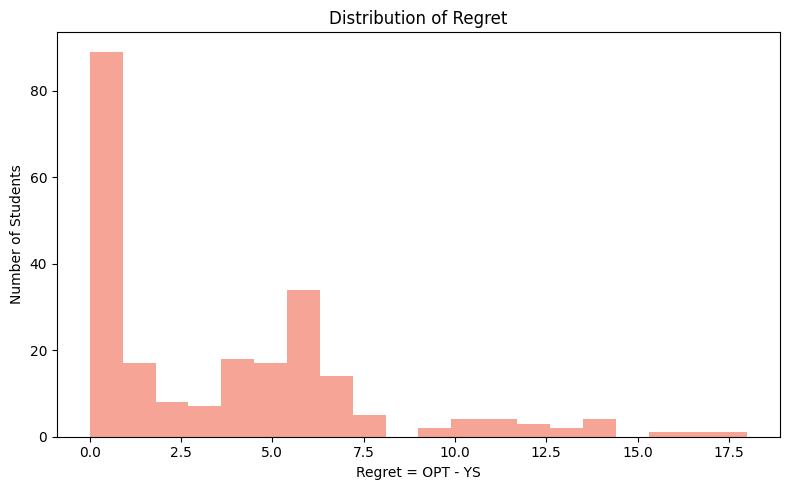

In [95]:
##############################################################################
# LOAD DATA
##############################################################################

df = pd.read_csv("manipulation_results_YS.csv")


##############################################################################
# TRUE UTILITIES
##############################################################################

OPT_utilities = np.diag(valuations @ X_OPT)
YS_utilities = np.diag(valuations @ X_YS)

regret = OPT_utilities - YS_utilities

num_students = len(regret)


##############################################################################
# MAX GAIN PER STUDENT
##############################################################################

max_gain_per_student = np.zeros(num_students)

if len(df) > 0:

    grouped = df.groupby("student")["gain"].max()

    for s, g in grouped.items():
        max_gain_per_student[int(s)] = g


##############################################################################
# STUDENTS THAT CAN GAIN
##############################################################################

can_gain = max_gain_per_student > 0


##############################################################################
# FIGURE 1
# REGRET DISTRIBUTION
##############################################################################

plt.figure(figsize=(8, 5))

plt.hist(regret, bins=20, color=faded_palette[1])

plt.xlabel("Regret = OPT - YS")
plt.ylabel("Number of Students")

plt.title("Distribution of Regret")

plt.tight_layout()
plt.show()

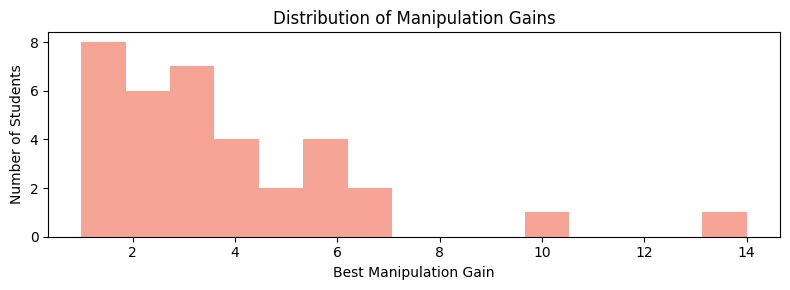

In [105]:
##############################################################################
# FIGURE 2
# MANIPULATION GAIN DISTRIBUTION
##############################################################################

positive_gains = max_gain_per_student[max_gain_per_student > 0]

plt.figure(figsize=(8, 3))

plt.hist(positive_gains, bins=15, color=faded_palette[1])

plt.xlabel("Best Manipulation Gain")
plt.ylabel("Number of Students")

plt.title("Distribution of Manipulation Gains")

plt.tight_layout()
plt.show()

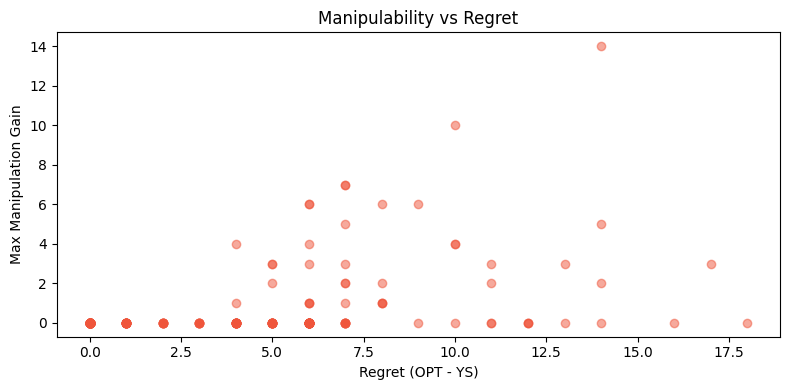

In [107]:
##############################################################################
# FIGURE 3
# REGRET VS MAX MANIPULATION GAIN
##############################################################################

plt.figure(figsize=(8, 4))

plt.scatter(
    regret,
    max_gain_per_student,
    color=faded_palette[1],
    alpha=0.5
)

plt.xlabel("Regret (OPT - YS)")
plt.ylabel("Max Manipulation Gain")

plt.title("Manipulability vs Regret")

plt.tight_layout()
plt.show()


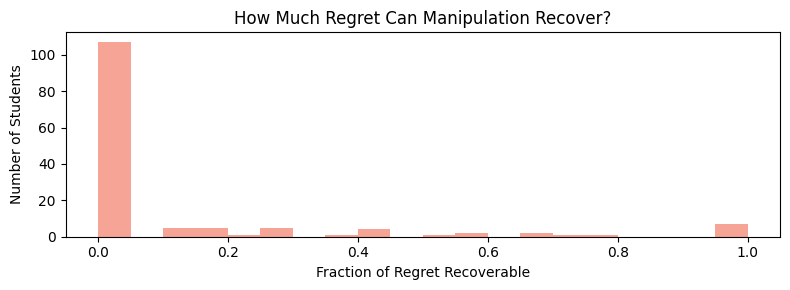

In [109]:
##############################################################################
# FIGURE 4
# FRACTION OF REGRET RECOVERED
##############################################################################

fraction_recovered = np.zeros(num_students)

positive_regret = regret > 0

fraction_recovered[positive_regret] = (
    max_gain_per_student[positive_regret]
    / regret[positive_regret]
)

plt.figure(figsize=(8, 3))

plt.hist(
    fraction_recovered[positive_regret],
    bins=20, 
    color=faded_palette[1]
)

plt.xlabel("Fraction of Regret Recoverable")
plt.ylabel("Number of Students")

plt.title("How Much Regret Can Manipulation Recover?")

plt.tight_layout()
plt.show()

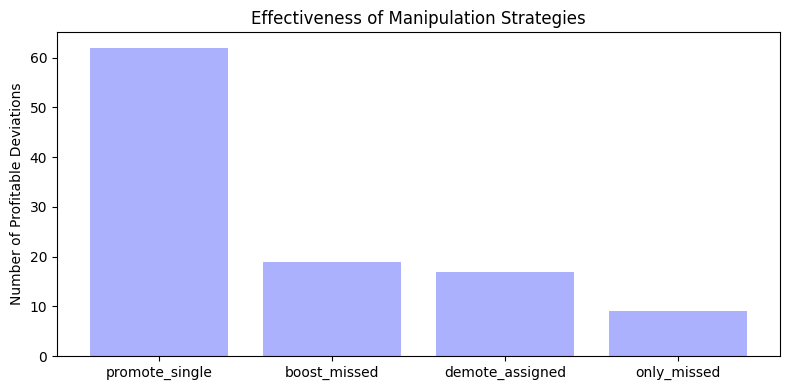

In [111]:


##############################################################################
# FIGURE 5
# WHICH STRATEGIES WORK BEST
##############################################################################

##############################################################################
# NORMALIZE STRATEGY NAMES
##############################################################################

df["strategy_group"] = df["strategy"].apply(
    lambda s: (
        "promote_single"
        if s.startswith("promote_single_")
        else s
    )
)

##############################################################################
# COUNT PROFITABLE DEVIATIONS
##############################################################################

strategy_counts = (
    df.groupby("strategy_group")["gain"]
    .count()
    .sort_values(ascending=False)
)
plt.figure(figsize=(8, 4))

plt.bar(
    strategy_counts.index,
    strategy_counts.values, 
    color=faded_palette[0]
)

plt.xticks(rotation=0)

plt.ylabel("Number of Profitable Deviations")

plt.title("Effectiveness of Manipulation Strategies")

plt.tight_layout()
plt.show()

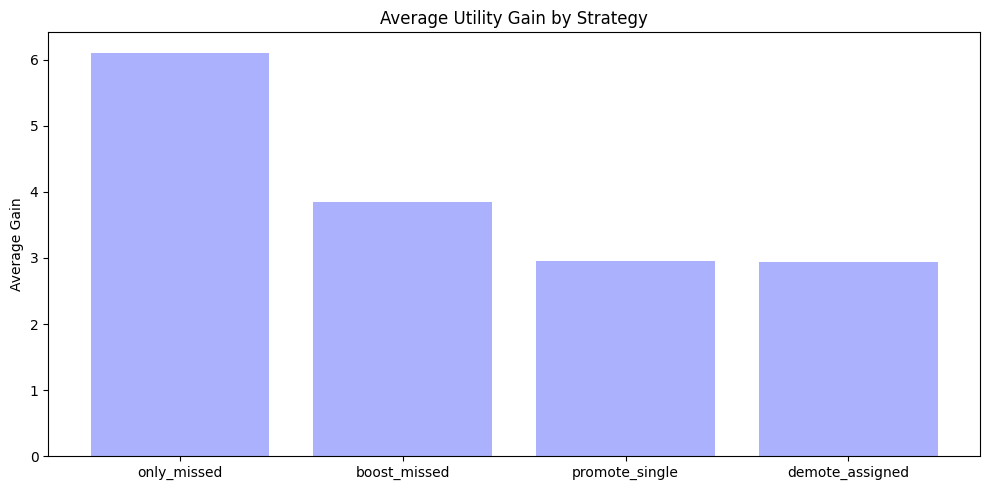

In [113]:
##############################################################################
# FIGURE 6
# AVERAGE GAIN BY STRATEGY
##############################################################################

strategy_avg_gain = (
    df.groupby("strategy_group")["gain"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    strategy_avg_gain.index,
    strategy_avg_gain.values, 
    color=faded_palette[0]
)

plt.xticks(rotation=0)

plt.ylabel("Average Gain")

plt.title("Average Utility Gain by Strategy")

plt.tight_layout()
plt.show()

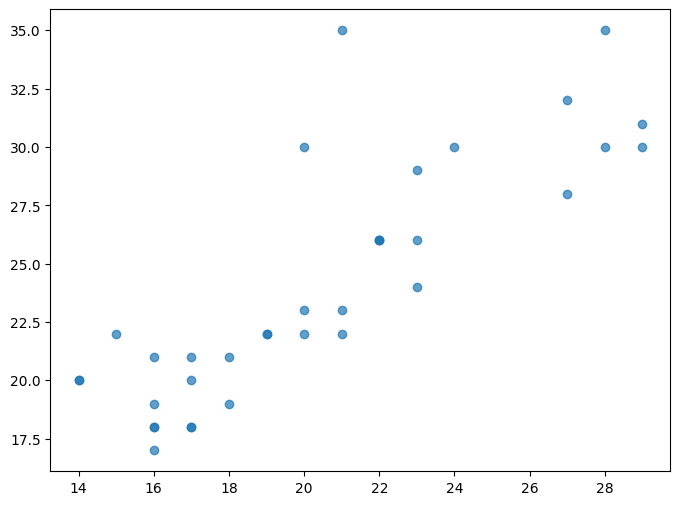

In [114]:

##############################################################################
# FIGURE 7
# TRUEFUL UTILITY VS MANIPULATED UTILITY
##############################################################################

best_rows = (
    df.sort_values("gain", ascending=False)
    .drop_duplicates("student")
)

plt.figure(figsize=(8, 6))

plt.scatter(
    best_rows["old_utility"],
    best_rows["new_utility"],
    alpha=0.7
)


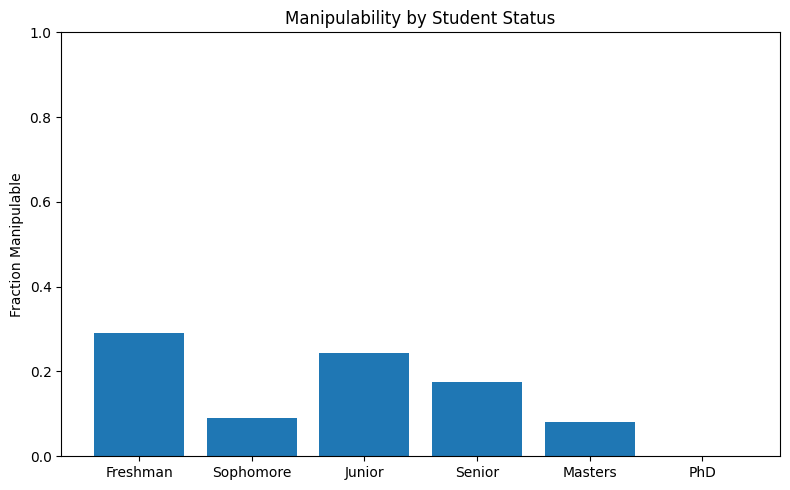

In [117]:

##############################################################################
# FIGURE 9
# STATUS VS MANIPULABILITY
##############################################################################

status_labels = {
    1: "Freshman",
    2: "Sophomore",
    3: "Junior",
    4: "Senior",
    5: "Masters",
    6: "PhD"
}

statuses = sorted(set(student_status_map.values()))

rates = []

for st in statuses:

    students_in_status = [
        s for s in range(num_students)
        if student_status_map[students[s]] == st
    ]

    if len(students_in_status) == 0:
        rates.append(0)
    else:

        manipulable_count = sum(
            can_gain[s]
            for s in students_in_status
        )

        rates.append(
            manipulable_count / len(students_in_status)
        )

plt.figure(figsize=(8, 5))

plt.bar(
    [status_labels[s] for s in statuses],
    rates
)

plt.ylim(0, 1)

plt.ylabel("Fraction Manipulable")

plt.title("Manipulability by Student Status")

plt.tight_layout()
plt.show()

